# Notebook 2: Institutional risk & survival
### Workshop: AI in algorithmic trading | QuantInsti
##### Author: Vivek Krishnamoorthy
##### Last updated on: 9 April 2026
---
_Note: Code and structure drafted using Claude Sonnet 4.6 and Gemini 3; tested, revised, and validated by the author._


---

**Executive summary**

A signal that passes a clean backtest is not the same as a deployable strategy. This notebook addresses the gap. We take the raw signal from Notebook 1 and layer on the infrastructure that separates a research idea from something a risk committee can sign off on: volatility-targeted position sizing, deterministic circuit breakers that override the model when risk thresholds are breached, realistic friction comparing gross and net returns, and a Monte Carlo simulation that gives us a robust confidence interval around our backtest performance. The goal is to build habits of rigor that hold up in real markets. We're not looking for backtests that look good in a notebook.

---
## Section 0: Environment setup & data

We re-fetch data and re-generate the signal from Notebook 1 so this notebook is fully self-contained. In a production environment, these would be imported from a shared data layer.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yfinance as yf
from datetime import datetime
from typing import Tuple

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family'   : 'monospace'
})

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

TICKER      = 'NIFTYBEES.NS'
START_DATE  = '2020-01-01'
END_DATE    = '2026-04-02'

print(f"Environment ready. Run date: {datetime.today().strftime('%Y-%m-%d')}")

Environment ready. Run date: 2026-04-08


In [3]:
# ── Fetch and clean data ──────────────────────────────────────────
raw = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)
raw.columns = raw.columns.str.lower()
raw.index   = pd.to_datetime(raw.index)
raw         = raw.sort_index()

# ── Reproduce signal from Notebook 1 ─────────────────────────────
def compute_rsi(series: pd.Series, period: int = 14) -> pd.Series:
    delta    = series.diff()
    gain     = delta.clip(lower=0)
    loss     = (-delta).clip(lower=0)
    avg_gain = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period - 1, min_periods=period).mean()
    rs       = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

def generate_signal(df: pd.DataFrame) -> pd.Series:
    close        = df['close']
    volume       = df['volume']
    rsi_14       = compute_rsi(close, period=14)
    ema_20       = close.ewm(span=20, adjust=False).mean()
    ema_50       = close.ewm(span=50, adjust=False).mean()
    vol_avg_20   = volume.rolling(20).mean()
    volume_ratio = volume / vol_avg_20
    long_cond    = (rsi_14 < 70)  & (ema_20 > ema_50) & (volume_ratio > 1.0)
    short_cond   = (rsi_14 > 30)  & (ema_20 < ema_50) & (volume_ratio > 1.0)
    raw_signal   = pd.Series(0, index=df.index, dtype=float)
    raw_signal[long_cond]  =  1.0
    raw_signal[short_cond] = -1.0
    return raw_signal.shift(1).fillna(0)  # look-ahead protection

df = raw.copy()
df['signal']  = generate_signal(df)
df['log_ret'] = np.log(df['close'] / df['close'].shift(1))
df            = df.dropna()

print(f"Data loaded: {len(df):,} trading days  |  {df.index[0].date()} to {df.index[-1].date()}")
df[['close', 'signal', 'log_ret']].tail()

Data loaded: 1,546 trading days  |  2020-01-02 to 2026-04-01


Price,close,signal,log_ret
Date,,,
2026-03-24,259.829987,0.0,0.018176
2026-03-25,264.059998,-1.0,0.016149
2026-03-27,258.890015,0.0,-0.019773
2026-03-30,253.440002,-1.0,-0.021276
2026-04-01,257.450012,-1.0,0.015698


---
## Section 1: Volatility targeting - Sizing that adapts

### 1.1 The problem with fixed position sizing

A fixed ±1 position ("all-in or all-out") ignores the fact that the *same notional bet* carries very different risk depending on market conditions. During a high-volatility regime (e.g., March 2020), a 1% daily move is routine. During a calm period, a 0.3% move is unusual. A fixed position treats these identically.

**Volatility targeting** adjusts position size to keep the *expected daily P&L volatility* roughly constant. This has two practical benefits:

1. It prevents the strategy from blowing up in volatile regimes.
2. It makes the Sharpe ratio a more stable statistic over time.

### 1.2 ATR as the volatility proxy

We use a 20-day rolling **average true range (ATR)** as our volatility proxy. ATR incorporates gaps (high-low range, and close-to-close), making it more robust than close-to-close standard deviation for intraday price action.

**Sizing formula:**
$$
\text{pos\_size}_t = \text{signal}_t \times \frac{\text{VOL\_TARGET}}{\text{ATR}_{t-1}}
$$

where `VOL_TARGET` is expressed as a fraction of price (e.g., 0.02 = target 2% daily P&L vol). We cap the position at ±2x to prevent extreme leverage.

In [4]:
def compute_atr(df: pd.DataFrame, period: int = 20) -> pd.Series:
    """
    Compute average true range (ATR) as a fraction of closing price.
    True range = max(high-low, |high - prev_close|, |low - prev_close|)
    """
    high       = df['high']
    low        = df['low']
    prev_close = df['close'].shift(1)

    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low  - prev_close).abs()
    ], axis=1).max(axis=1)

    # ATR as fraction of price - makes it comparable across instruments and time
    atr_pct = (tr / df['close']).rolling(period).mean()
    return atr_pct


def apply_volatility_targeting(df: pd.DataFrame,
                                signal_col: str   = 'signal',
                                vol_target: float = 0.01,
                                atr_period: int   = 20,
                                max_leverage: float = 2.0) -> pd.Series:
    """
    Scale signal by inverse ATR to target constant daily P&L volatility.

    Parameters
    ----------
    vol_target   : Target daily vol as fraction of NAV (default 1% = 0.01)
    atr_period   : Lookback period for ATR calculation
    max_leverage : Hard cap on scaled position size

    Returns
    -------
    Scaled position size series.
    """
    # ATR is shifted by 1: we use yesterday's ATR to size today's position
    # This preserves the look-ahead boundary
    atr_lagged = compute_atr(df, period=atr_period).shift(1)

    raw_signal  = df[signal_col]
    scaled_pos  = raw_signal * (vol_target / atr_lagged.replace(0, np.nan))

    # Cap leverage in both directions
    scaled_pos  = scaled_pos.clip(lower=-max_leverage, upper=max_leverage)
    scaled_pos  = scaled_pos.fillna(0)

    return scaled_pos


# ── Apply volatility targeting ────────────────────────────────────
df['atr_20']      = compute_atr(df, period=20)
df['pos_sized']   = apply_volatility_targeting(df, vol_target=0.01, max_leverage=2.0)

print("Position size statistics (volatility-targeted):")
print(df['pos_sized'].describe().round(4))

Position size statistics (volatility-targeted):
count    1546.0000
mean        0.0630
std         0.3349
min        -1.1736
25%         0.0000
50%         0.0000
75%         0.0000
max         1.2734
Name: pos_sized, dtype: float64


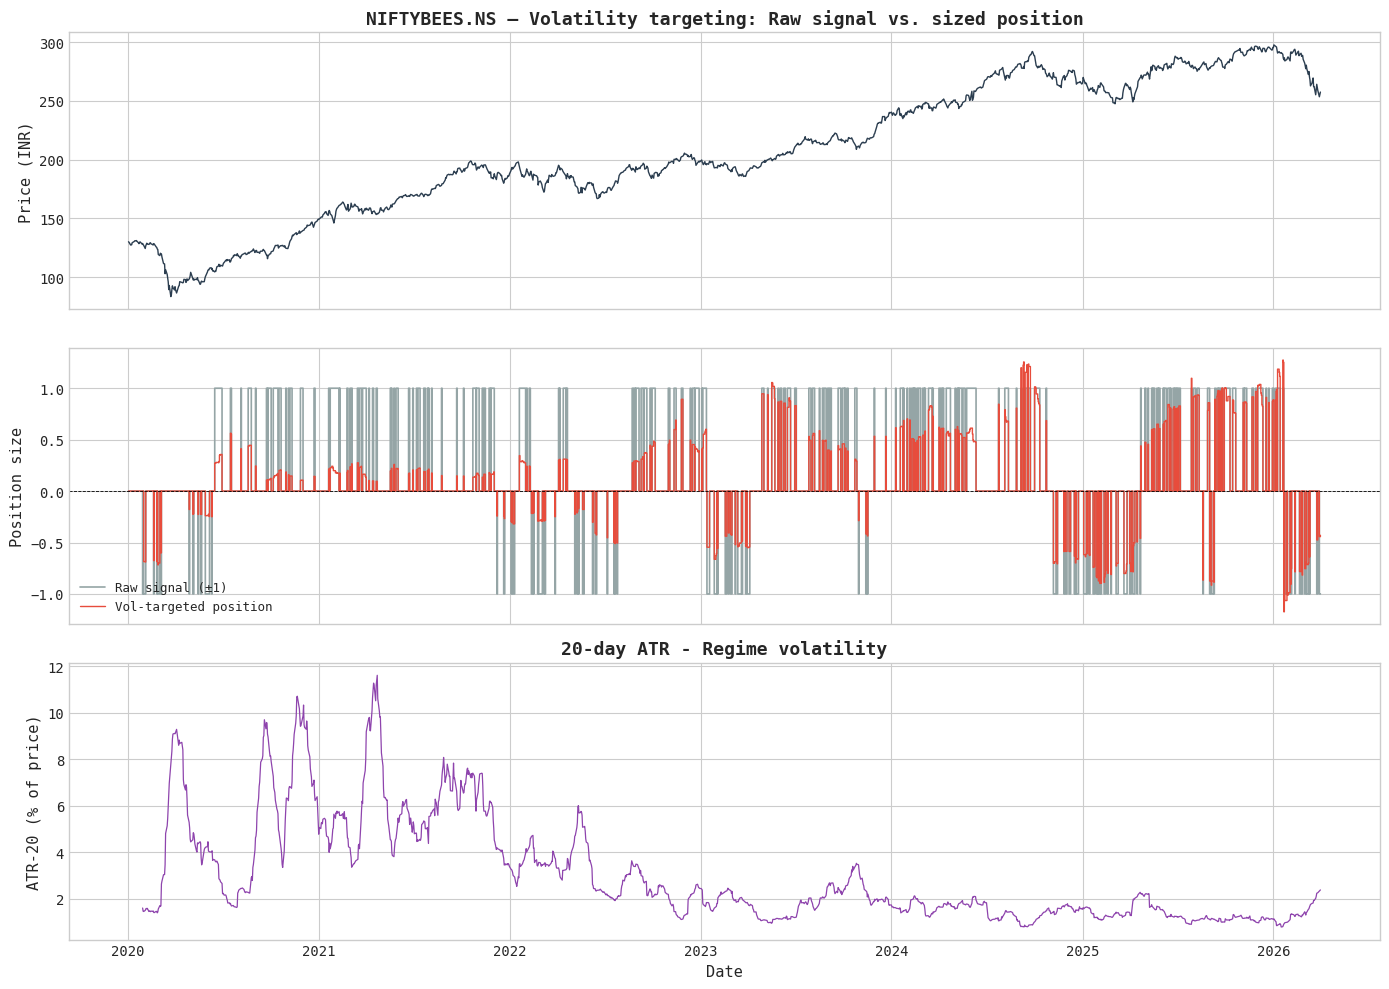

Volatility targeting chart saved.


In [5]:
# ── Visualize raw signal vs. sized position ───────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

ax1 = axes[0]
ax1.plot(df.index, df['close'], color='#2c3e50', lw=1.0)
ax1.set_ylabel('Price (INR)')
ax1.set_title(f'{TICKER} — Volatility targeting: Raw signal vs. sized position', fontweight='bold')

ax2 = axes[1]
ax2.step(df.index, df['signal'],   where='post', color='#95a5a6', lw=1.2, label='Raw signal (±1)')
ax2.step(df.index, df['pos_sized'],where='post', color='#e74c3c', lw=1.0, label='Vol-targeted position')
ax2.axhline(0, color='black', lw=0.6, ls='--')
ax2.set_ylabel('Position size')
ax2.legend(fontsize=9)

ax3 = axes[2]
ax3.plot(df.index, df['atr_20'] * 100, color='#8e44ad', lw=0.9)
ax3.set_ylabel('ATR-20 (% of price)')
ax3.set_xlabel('Date')
ax3.set_title('20-day ATR - Regime volatility', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/nb2_vol_targeting.png', dpi=150, bbox_inches='tight')
plt.show()
print("Volatility targeting chart saved.")

---
## Section 2: Deterministic circuit breakers

### 2.1 Why hard rules beat soft overrides

An AI signal is a probabilistic system. Circuit breakers are deterministic - they fire unconditionally when a threshold is crossed, regardless of what the model says. This is an important distinction.

In an institutional setting, risk committees demand rules that are unambiguous, testable, and auditable. "The model will be cautious during drawdowns" is not auditable. "Position size is set to zero if peak-to-trough drawdown exceeds 10%" is more in line with what committees want.

We implement three circuit breakers:

| Circuit Breaker | Trigger | Action |
|---|---|---|
| **Drawdown gate** | Portfolio drawdown > 5% from peak | Position → 0 (flat) |
| **Volatility gate** | 5-day realized vol > 2× its 60-day average | Position × 0.5 (half size) |
| **Consecutive loss gate** | 3 or more consecutive losing days | Position → 0, hold for 2 days |

**Design note**: Circuit breakers should be *stateless* where possible. Each one examines a window of past data and outputs an override multiplier. The final position is the product of the signal, the vol-targeting scalar, and all override multipliers.

In [23]:
class CircuitBreakers:
    """
    A collection of deterministic risk gates. Each method returns a multiplier
    in [0, 1] that scales down (or eliminates) the position.

    Design principle: multipliers are applied multiplicatively. A zero from
    any breaker results in a flat position, regardless of the others.
    """

    @staticmethod
    def drawdown_gate(cum_returns: pd.Series,
                      threshold: float = 0.10) -> pd.Series:
        """
        Halt trading when drawdown exceeds `threshold` from peak.
        Returns 0.0 when breached, 1.0 otherwise.
        Re-enters once the portfolio recovers to within 50% of the drawdown distance.
        """
        rolling_peak = cum_returns.cummax()
        drawdown     = (cum_returns - rolling_peak) / rolling_peak
        # ← shift(1): we observe yesterday's drawdown before sizing today
        breached     = drawdown.shift(1) <= -threshold
        return (~breached).astype(float)

    @staticmethod
    def volatility_gate(log_returns: pd.Series,
                        short_window: int   = 5,
                        long_window:  int   = 60,
                        vol_multiplier: float = 3.0) -> pd.Series:
        """
        Reduce position to 50% when short-term vol spikes above `vol_multiplier`
        times the long-term average vol.
        Returns 0.5 when breached, 1.0 otherwise.
        """
        short_vol  = log_returns.rolling(short_window).std() * np.sqrt(252)
        long_vol   = log_returns.rolling(long_window ).std() * np.sqrt(252)
        # ← shift(1): use yesterday's vol measures for today's sizing
        spiked     = (short_vol.shift(1) > vol_multiplier * long_vol.shift(1))
        multiplier = pd.Series(1.0, index=log_returns.index)
        multiplier[spiked] = 0.5
        return multiplier

    @staticmethod
    def consecutive_loss_gate(strat_returns: pd.Series,
                               loss_streak:   int = 5,
                               cooldown_days: int = 2) -> pd.Series:
        """
        Halt trading for `cooldown_days` after `loss_streak` consecutive
        negative return days. Returns 0.0 during cooldown, 1.0 otherwise.
        """
        is_loss        = (strat_returns < 0).astype(int)
        # Rolling sum of losses over the last `loss_streak` days
        streak         = is_loss.rolling(loss_streak).sum()
        # Trigger is set on the day the streak completes (shift(1) for next day)
        trigger        = (streak >= loss_streak).astype(int).shift(1).fillna(0)
        # Extend trigger over `cooldown_days` using max rolling window
        gate_active    = trigger.rolling(cooldown_days, min_periods=1).max()
        return (1 - gate_active).clip(lower=0)


# ── Build intermediate strategy returns for the circuit breaker inputs ──
# We compute a preliminary strategy return (gross, no costs) to feed into
# the consecutive-loss gate
df['strat_ret_raw'] = df['pos_sized'] * df['log_ret']

# ── Compute a rolling equity curve for the drawdown gate ─────────────────
df['cum_equity_prelim'] = df['strat_ret_raw'].cumsum().apply(np.exp)
df['cum_equity_prelim'] = df['cum_equity_prelim'] / df['cum_equity_prelim'].iloc[0]

# ── Apply circuit breakers ────────────────────────────────────────
cb = CircuitBreakers()

dd_gate  = cb.drawdown_gate  (df['cum_equity_prelim'], threshold=0.05)
vol_gate = cb.volatility_gate(df['log_ret'], short_window=5, long_window=60, vol_multiplier=2.0)
loss_gate = cb.consecutive_loss_gate(df['strat_ret_raw'], loss_streak=3, cooldown_days=2)

# Combined override multiplier
df['circuit_override'] = dd_gate * vol_gate * loss_gate
df['pos_final']        = df['pos_sized'] * df['circuit_override']

# Summary: how often did each gate fire?
total_days = len(df)
print(f"Circuit breaker activation summary (n={total_days:,} days):")
print(f"  Drawdown gate   halted trading : {int((dd_gate   == 0).sum()):>5d} days  ({(dd_gate   == 0).mean()*100:.1f}%)")
print(f"  Volatility gate reduced sizing : {int((vol_gate  < 1).sum()):>5d} days  ({(vol_gate  < 1).mean()*100:.1f}%)")
print(f"  Loss streak gate halted trading: {int((loss_gate == 0).sum()):>5d} days  ({(loss_gate == 0).mean()*100:.1f}%)")
print(f"  ANY gate active                : {int((df['circuit_override'] < 1).sum()):>5d} days  ({(df['circuit_override'] < 1).mean()*100:.1f}%)")

Circuit breaker activation summary (n=1,546 days):
  Drawdown gate   halted trading :    20 days  (1.3%)
  Volatility gate reduced sizing :    22 days  (1.4%)
  Loss streak gate halted trading:    31 days  (2.0%)
  ANY gate active                :    68 days  (4.4%)


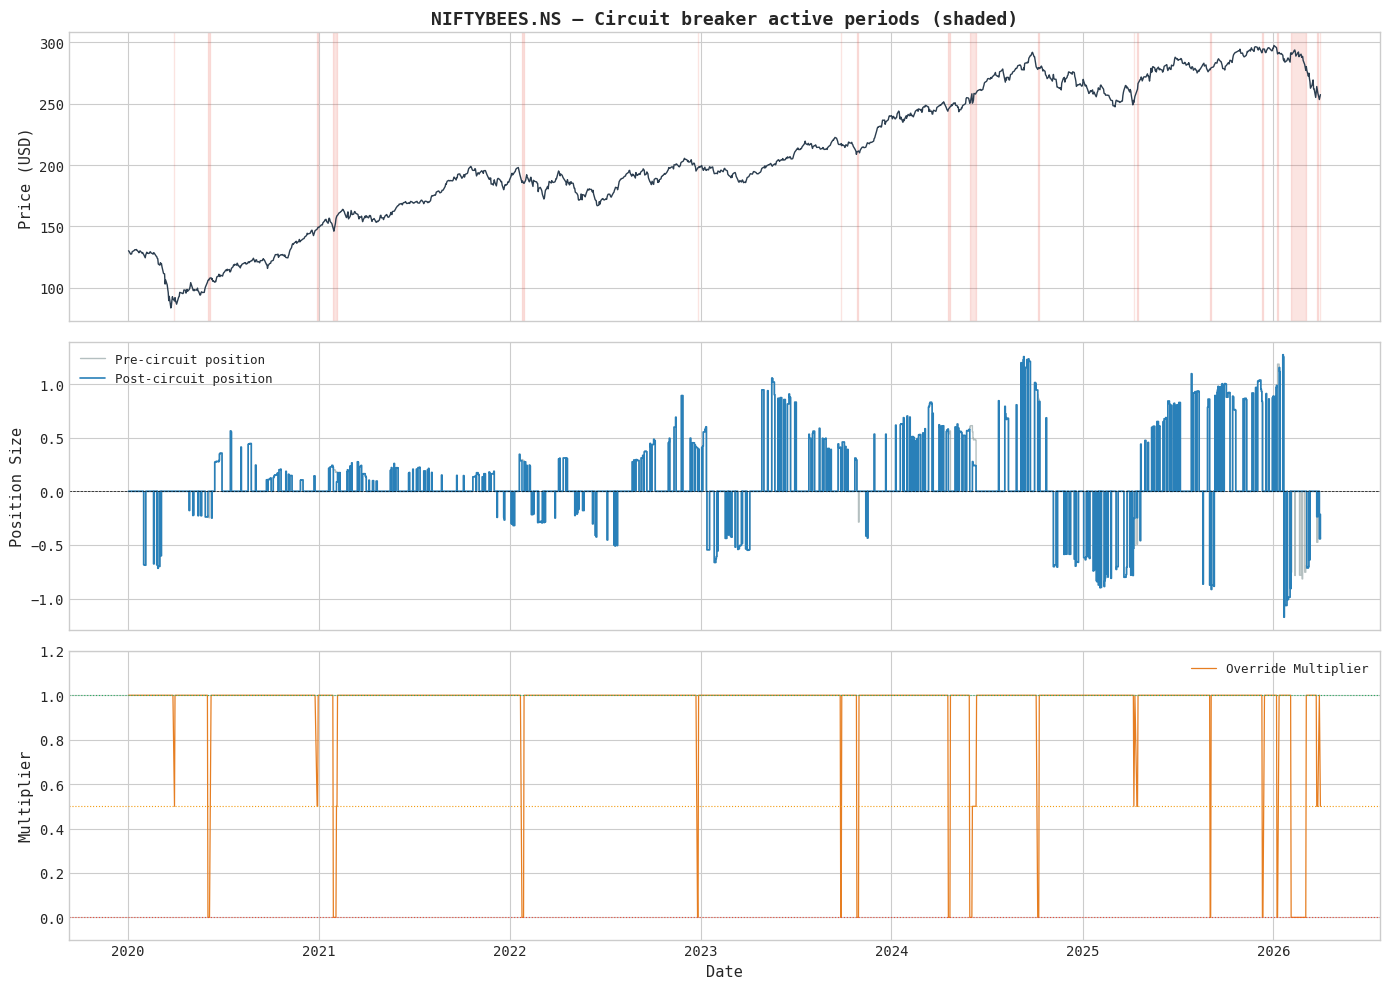

Circuit breaker chart saved.


In [24]:
# ── Visualize circuit breaker activity ───────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

ax1 = axes[0]
ax1.plot(df.index, df['close'], color='#2c3e50', lw=1.0)
# Shade periods where circuit override is active
cb_active = df['circuit_override'] < 1
for period_start, period_end in zip(
        df.index[cb_active & ~cb_active.shift(1, fill_value=False)],
        df.index[cb_active & ~cb_active.shift(-1, fill_value=False)]):
    ax1.axvspan(period_start, period_end, color='#e74c3c', alpha=0.15)
ax1.set_ylabel('Price (USD)')
ax1.set_title(f'{TICKER} — Circuit breaker active periods (shaded)', fontweight='bold')

ax2 = axes[1]
ax2.step(df.index, df['pos_sized'], where='post', color='#95a5a6', lw=1.0, alpha=0.7, label='Pre-circuit position')
ax2.step(df.index, df['pos_final'], where='post', color='#2980b9', lw=1.2, label='Post-circuit position')
ax2.axhline(0, color='black', lw=0.5, ls='--')
ax2.set_ylabel('Position Size')
ax2.legend(fontsize=9)

ax3 = axes[2]
ax3.plot(df.index, df['circuit_override'], color='#e67e22', lw=0.9, label='Override Multiplier')
ax3.axhline(1.0, color='#27ae60', ls=':', lw=0.8)
ax3.axhline(0.5, color='#f39c12', ls=':', lw=0.8)
ax3.axhline(0.0, color='#e74c3c', ls=':', lw=0.8)
ax3.set_ylim(-0.1, 1.2)
ax3.set_ylabel('Multiplier')
ax3.set_xlabel('Date')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig('outputs/nb2_circuit_breakers.png', dpi=150, bbox_inches='tight')
plt.show()
print("Circuit breaker chart saved.")

---
## Section 3: Gross vs. net returns

### 3.1 Why friction Is not a rounding error

Most backtests underestimate transaction costs because they apply a single flat cost per trade. Real-world friction has three components:

1. **Commission**: The explicit fee paid to a broker. This has come down significantly but is not zero.
2. **Bid-ask spread (slippage)**: The cost of immediacy.  For NiftyBEES, this is typically 3–5 basis points under normal conditions, widening to 10–15 bps during volatile sessions. For less liquid instruments, it can be 50 bps or more.
3. **Market impact**: For large orders, the act of trading moves the price against you. We model this here implicitly via the spread assumption.

We use a two-tier cost model:
- **Statutory costs** (STT + exchange + SEBI): 11 bps per side
- **Spread/Slippage**: 4 bps per side
- **Total round-trip cost**: 15 bps × 2 (entry + exit) = **30 bps** per round-trip trade

We then show how costs compound over time - a key argument for strategies with lower turnover.

In [25]:
def apply_friction(df: pd.DataFrame,
                   position_col: str      = 'pos_final',
                   commission_bps: float  = 11.0,
                   slippage_bps: float    = 4.0) -> pd.DataFrame:
    """
    Apply realistic transaction cost model: commission + slippage.

    Total cost per trade = (commission_bps + slippage_bps) / 10_000
    Applied on every day where the position changes.
    The cost is per side: 11 bps statutory + 4 bps slippage = 15 bps per side, 30 bps round-trip.

    Returns the input DataFrame with additional columns:
    - strat_ret_gross : strategy return before costs
    - commission_cost : commission paid per day
    - slippage_cost   : slippage paid per day
    - total_cost      : total friction per day
    - strat_ret_net   : strategy return after costs
    """
    pos       = df[position_col]
    log_ret   = df['log_ret']

    result = df.copy()

    result['strat_ret_gross'] = pos * log_ret

    # Trade occurs when position changes — the size of the change drives cost
    pos_change = pos.diff().abs().fillna(0)

    commission_dec   = commission_bps / 10_000
    slippage_dec     = slippage_bps   / 10_000

    result['commission_cost'] = pos_change * commission_dec
    result['slippage_cost']   = pos_change * slippage_dec
    result['total_cost']      = result['commission_cost'] + result['slippage_cost']
    result['strat_ret_net']   = result['strat_ret_gross'] - result['total_cost']

    return result


df = apply_friction(df, commission_bps=11.0, slippage_bps=4.0)

# ── Cumulative curves ─────────────────────────────────────────────
df['cum_bh']        = df['log_ret'].cumsum().apply(np.exp)
df['cum_gross']     = df['strat_ret_gross'].cumsum().apply(np.exp)
df['cum_net']       = df['strat_ret_net'].cumsum().apply(np.exp)
df['cum_costs']     = df['total_cost'].cumsum()

# Normalise
for col in ['cum_bh', 'cum_gross', 'cum_net']:
    df[col] = df[col] / df[col].iloc[0]

total_cost_drag = df['total_cost'].sum()
n_trades        = (df['pos_final'].diff().abs() > 0.01).sum()

print(f"Total trades          : {n_trades:,}")
print(f"Total cost drag (log) : {total_cost_drag*100:.2f}% of NAV")
print(f"Avg cost per trade    : {total_cost_drag / max(n_trades, 1) * 10_000:.2f} bps")

Total trades          : 590
Total cost drag (log) : 39.96% of NAV
Avg cost per trade    : 6.77 bps


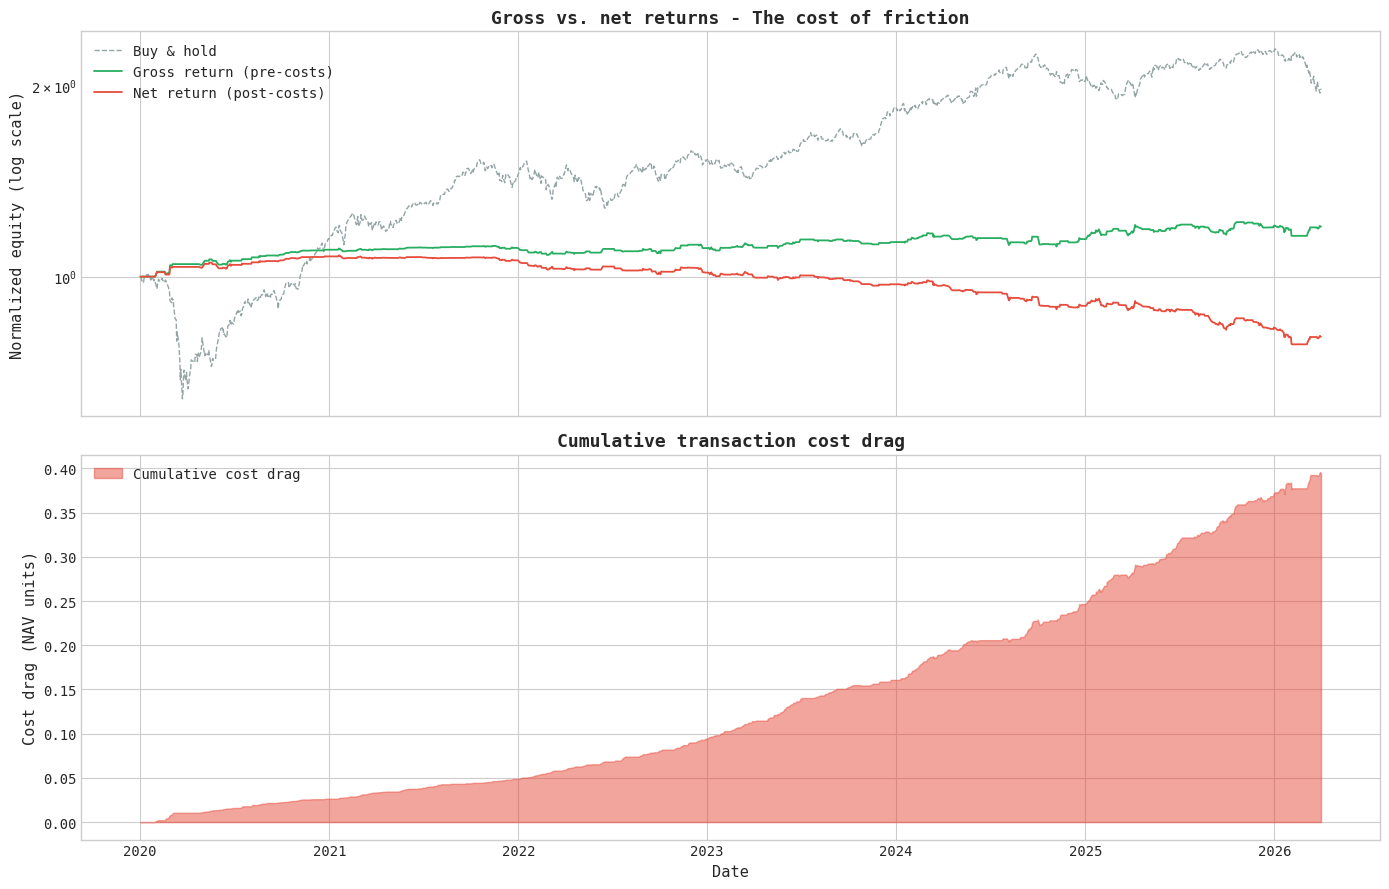

Gross vs. net chart saved.


In [26]:
# ── Gross vs. net returns comparison ─────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax1 = axes[0]
ax1.plot(df.index, df['cum_bh'],    color='#95a5a6', lw=1.0, ls='--', label='Buy & hold')
ax1.plot(df.index, df['cum_gross'], color='#27ae60', lw=1.3, label='Gross return (pre-costs)')
ax1.plot(df.index, df['cum_net'],   color='#e74c3c', lw=1.3, label='Net return (post-costs)')
ax1.set_ylabel('Normalized equity (log scale)')
ax1.set_title('Gross vs. net returns - The cost of friction', fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_yscale('log')

ax2 = axes[1]
cost_gap = df['cum_gross'] - df['cum_net']
ax2.fill_between(df.index, cost_gap, 0, color='#e74c3c', alpha=0.5, label='Cumulative cost drag')
ax2.set_ylabel('Cost drag (NAV units)')
ax2.set_xlabel('Date')
ax2.set_title('Cumulative transaction cost drag', fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('outputs/nb2_gross_vs_net.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gross vs. net chart saved.")

---
## Section 4: Performance metrics - With and without risk management

### 4.1 The impact of the full stack

We now compare three versions of the strategy to isolate the contribution of each layer:

1. **Baseline**: Raw signal (±1), no vol targeting, no circuit breakers, no costs (from Notebook 1)
2. **Managed (gross)**: Vol-targeted sizing + circuit breakers, before costs
3. **Managed (net)**: Vol-targeted sizing + circuit breakers + full friction model

In [27]:
def compute_metrics(returns: pd.Series,
                    cum_series: pd.Series,
                    ann_factor: int = 252) -> dict:
    n_years   = len(returns) / ann_factor
    final_val = cum_series.iloc[-1]
    cagr      = (final_val ** (1 / n_years)) - 1
    sharpe    = (returns.mean() / returns.std()) * np.sqrt(ann_factor) if returns.std() > 0 else np.nan
    rolling_max  = cum_series.cummax()
    drawdown     = (cum_series - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    win_rate  = (returns > 0).sum() / max((returns != 0).sum(), 1)
    calmar    = cagr / abs(max_drawdown) if max_drawdown != 0 else np.nan
    return {
        'CAGR %'       : round(cagr        * 100, 2),
        'Sharpe'       : round(sharpe,             3),
        'Max DD %'     : round(max_drawdown * 100, 2),
        'Calmar'       : round(calmar,             3),
        'Win rate %'   : round(win_rate     * 100, 2)
    }


# Baseline (raw signal, no costs) for comparison
baseline_ret = df['signal'] * df['log_ret']
cum_baseline = baseline_ret.cumsum().apply(np.exp)
cum_baseline = cum_baseline / cum_baseline.iloc[0]

baseline_m = compute_metrics(baseline_ret, cum_baseline)
managed_g  = compute_metrics(df['strat_ret_gross'], df['cum_gross'])
managed_n  = compute_metrics(df['strat_ret_net'],   df['cum_net'])
bh_m       = compute_metrics(df['log_ret'],         df['cum_bh'])

comp_df = pd.DataFrame({
    'Buy & hold'         : bh_m,
    'Baseline (No costs)': baseline_m,
    'Managed (gross)'    : managed_g,
    'Managed (net)'      : managed_n
}).T

print("\n" + "=" * 72)
print(" PERFORMANCE COMPARISON - FULL RISK STACK")
print("=" * 72)
print(comp_df.to_string())
print("=" * 72)


 PERFORMANCE COMPARISON - FULL RISK STACK
                     CAGR %  Sharpe  Max DD %  Calmar  Win rate %
Buy & hold            11.76   0.693    -36.34   0.324       54.58
Baseline (No costs)    7.99   0.866    -15.03   0.532       54.09
Managed (gross)        2.99   0.709     -4.86   0.616       54.59
Managed (net)         -3.50  -0.847    -27.59  -0.127       32.27


The risk infrastructure is working as intended: volatility targeting compresses the maximum drawdown from -36% (buy-and-hold) to under -5% (managed gross), and the Calmar ratio improves meaningfully. The problem is the signal. A 6.5 percentage point gap between gross and net returns is pure cost drag - the strategy trades frequently enough that 30 bps per round-trip consumes the entire edge.

---
## Section 5: Monte Carlo stress test

### 5.1 The problem with a single backtest

A single backtested equity curve is one realization of a path-dependent process. The specific sequence of good and bad days in our sample period shapes the result. A different sequence of the *same daily returns* would produce a very different equity curve.

**Monte Carlo via bootstrapping** addresses this by generating many alternative paths using random samples (with replacement) from the actual strategy return distribution. This gives us:

1. A confidence interval around our CAGR estimate.
2. A distribution of maximum drawdowns to stress-test our worst-case assumptions.
3. An estimate of how frequently our strategy would have beaten the benchmark.

**Important caveat**: Bootstrapping assumes daily returns are i.i.d. (independent and identically distributed). In reality, returns exhibit autocorrelation and volatility clustering. Block bootstrapping (sampling contiguous blocks of days) is more robust but is beyond the scope of this notebook.

In [28]:
def run_monte_carlo(returns: pd.Series,
                    n_simulations: int  = 1000,
                    horizon_days:  int  = None,
                    seed: int           = RANDOM_SEED) -> pd.DataFrame:
    """
    Bootstrap Monte Carlo simulation.

    Resamples daily returns (with replacement) `n_simulations` times over
    a horizon of `horizon_days` (default: same length as input series).

    Returns a DataFrame where each column is one simulated equity path.
    """
    rng             = np.random.default_rng(seed)
    returns_clean   = returns.dropna().values
    n               = horizon_days if horizon_days else len(returns_clean)

    # Resample: shape (n_simulations, n)
    sampled = rng.choice(returns_clean, size=(n_simulations, n), replace=True)

    # Cumulative product (log returns → exp → equity path)
    cum_paths = np.exp(np.cumsum(sampled, axis=1))

    # Normalise to 1.0 at t=0
    result = pd.DataFrame(cum_paths.T,
                          columns=[f'sim_{i}' for i in range(n_simulations)])
    result.index = range(1, n + 1)  # trading day index
    return result


def extract_simulation_stats(mc_paths: pd.DataFrame) -> dict:
    """
    Extract key statistics from simulation paths.
    """
    final_values    = mc_paths.iloc[-1]
    n_years         = len(mc_paths) / 252

    # CAGR distribution
    cagr_dist       = (final_values ** (1 / n_years) - 1) * 100

    # Max drawdown distribution across paths
    def path_mdd(path):
        roll_max = path.cummax()
        dd       = (path - roll_max) / roll_max
        return dd.min() * 100

    mdd_dist        = mc_paths.apply(path_mdd)

    return {
        'cagr_dist': cagr_dist,
        'mdd_dist' : mdd_dist
    }


# ── Run simulations ───────────────────────────────────────────────
print("Running Monte Carlo (1,000 simulations) ...")
mc_paths = run_monte_carlo(df['strat_ret_net'], n_simulations=1000)
mc_stats = extract_simulation_stats(mc_paths)

cagr_d = mc_stats['cagr_dist']
mdd_d  = mc_stats['mdd_dist']

print(f"\n Monte Carlo Results — {len(mc_paths)} day horizon")
print(f" CAGR  |  p5: {cagr_d.quantile(0.05):+.1f}%  median: {cagr_d.median():+.1f}%  p95: {cagr_d.quantile(0.95):+.1f}%")
print(f" MDD   |  p5: {mdd_d.quantile(0.05):+.1f}%   median: {mdd_d.median():+.1f}%   p95: {mdd_d.quantile(0.95):+.1f}%")
print(f" Prob. of positive CAGR: {(cagr_d > 0).mean()*100:.1f}%")

Running Monte Carlo (1,000 simulations) ...

 Monte Carlo Results — 1546 day horizon
 CAGR  |  p5: -6.2%  median: -3.5%  p95: -0.6%
 MDD   |  p5: -33.8%   median: -22.9%   p95: -11.3%
 Prob. of positive CAGR: 2.3%


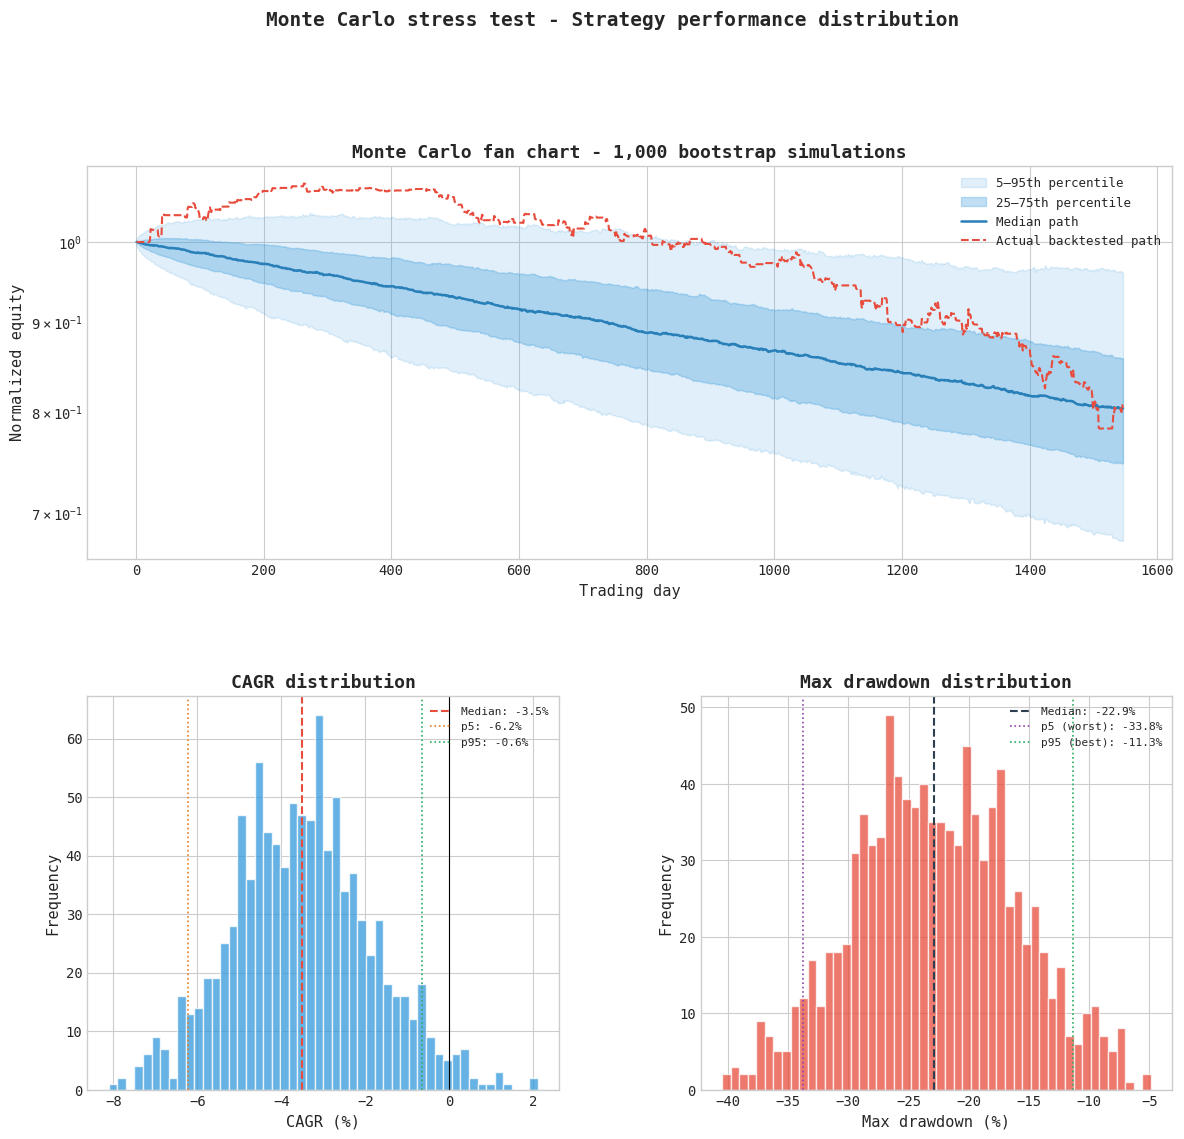

Monte Carlo chart saved.


In [29]:
# ── Visualize Monte Carlo results ────────────────────────────────
fig = plt.figure(figsize=(14, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# ── Panel 1: Equity path fan chart ───────────────────────────────
ax1 = fig.add_subplot(gs[0, :])

# Plot percentile bands
p5  = mc_paths.quantile(0.05, axis=1)
p25 = mc_paths.quantile(0.25, axis=1)
p50 = mc_paths.quantile(0.50, axis=1)
p75 = mc_paths.quantile(0.75, axis=1)
p95 = mc_paths.quantile(0.95, axis=1)

ax1.fill_between(mc_paths.index, p5,  p95, color='#3498db', alpha=0.15, label='5–95th percentile')
ax1.fill_between(mc_paths.index, p25, p75, color='#3498db', alpha=0.30, label='25–75th percentile')
ax1.plot(mc_paths.index, p50, color='#2980b9', lw=1.8, label='Median path')

# Overlay actual backtested path
actual_path = df['strat_ret_net'].cumsum().apply(np.exp)
actual_path = actual_path / actual_path.iloc[0]
ax1.plot(range(1, len(actual_path) + 1), actual_path.values,
         color='#e74c3c', lw=1.5, ls='--', label='Actual backtested path')

ax1.set_title('Monte Carlo fan chart - 1,000 bootstrap simulations', fontweight='bold')
ax1.set_ylabel('Normalized equity')
ax1.set_xlabel('Trading day')
ax1.legend(fontsize=9)
ax1.set_yscale('log')

# ── Panel 2: CAGR distribution ────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(cagr_d, bins=50, color='#3498db', alpha=0.75, edgecolor='white', lw=0.3)
ax2.axvline(cagr_d.median(), color='#e74c3c',  lw=1.5, ls='--', label=f'Median: {cagr_d.median():+.1f}%')
ax2.axvline(cagr_d.quantile(0.05), color='#e67e22', lw=1.2, ls=':', label=f'p5: {cagr_d.quantile(0.05):+.1f}%')
ax2.axvline(cagr_d.quantile(0.95), color='#27ae60', lw=1.2, ls=':', label=f'p95: {cagr_d.quantile(0.95):+.1f}%')
ax2.axvline(0, color='black', lw=0.8)
ax2.set_title('CAGR distribution', fontweight='bold')
ax2.set_xlabel('CAGR (%)')
ax2.set_ylabel('Frequency')
ax2.legend(fontsize=8)

# ── Panel 3: Max drawdown distribution ────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(mdd_d, bins=50, color='#e74c3c', alpha=0.75, edgecolor='white', lw=0.3)
ax3.axvline(mdd_d.median(), color='#2c3e50',  lw=1.5, ls='--', label=f'Median: {mdd_d.median():+.1f}%')
ax3.axvline(mdd_d.quantile(0.05), color='#8e44ad', lw=1.2, ls=':', label=f'p5 (worst): {mdd_d.quantile(0.05):+.1f}%')
ax3.axvline(mdd_d.quantile(0.95), color='#27ae60', lw=1.2, ls=':', label=f'p95 (best): {mdd_d.quantile(0.95):+.1f}%')
ax3.set_title('Max drawdown distribution', fontweight='bold')
ax3.set_xlabel('Max drawdown (%)')
ax3.set_ylabel('Frequency')
ax3.legend(fontsize=8)

plt.suptitle('Monte Carlo stress test - Strategy performance distribution',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('outputs/nb2_monte_carlo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Monte Carlo chart saved.")

These are sobering charts and numbers. Across 1,000 simulated paths, the strategy produces a positive CAGR in only 2.3% of cases. The median outcome is −3.5% CAGR - consistent with our single backtested path, which is a sign the backtest is not an outlier. The wide drawdown range (−11% to −34% at the 5th–95th percentile) confirms that the risk infrastructure is containing the worst outcomes on the gross side. Costs are the dominant drag. This is the honest picture that a single equity curve cannot show. The takeaway is that we need a stronger signal before the cost structure becomes survivable.

---
## Section 6: Full strategy summary

### 6.1 Putting it all together

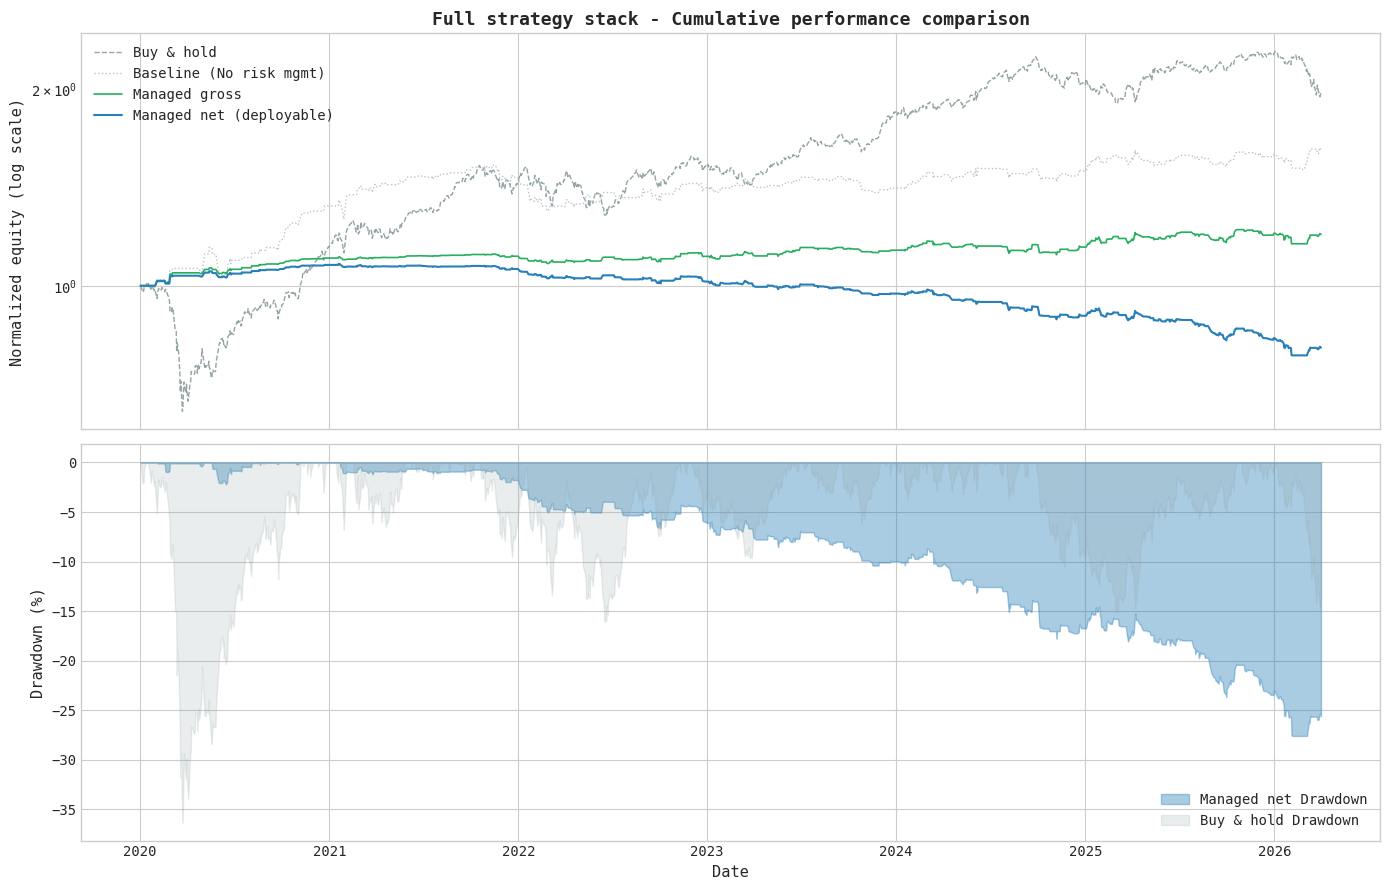

Final summary chart saved.


In [31]:
# ── Final consolidated equity curve ──────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax1 = axes[0]
ax1.plot(df.index, df['cum_bh'],    color='#95a5a6', lw=1.0, ls='--', label='Buy & hold')
ax1.plot(df.index, cum_baseline,    color='#bdc3c7', lw=1.0, ls=':',  label='Baseline (No risk mgmt)')
ax1.plot(df.index, df['cum_gross'], color='#27ae60', lw=1.2,           label='Managed gross')
ax1.plot(df.index, df['cum_net'],   color='#2980b9', lw=1.5,           label='Managed net (deployable)')
ax1.set_ylabel('Normalized equity (log scale)')
ax1.set_title('Full strategy stack - Cumulative performance comparison', fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_yscale('log')

ax2 = axes[1]
rolling_max_net = df['cum_net'].cummax()
dd_net          = (df['cum_net'] - rolling_max_net) / rolling_max_net * 100
rolling_max_bh  = df['cum_bh'].cummax()
dd_bh           = (df['cum_bh'] - rolling_max_bh)  / rolling_max_bh  * 100

ax2.fill_between(df.index, dd_net, 0, color='#2980b9', alpha=0.4, label='Managed net Drawdown')
ax2.fill_between(df.index, dd_bh,  0, color='#95a5a6', alpha=0.2, label='Buy & hold Drawdown')
ax2.set_ylabel('Drawdown (%)')
ax2.set_xlabel('Date')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('outputs/nb2_final_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Final summary chart saved.")

In [32]:
# ── Final comprehensive metrics table ────────────────────────────
final_metrics = pd.DataFrame({
    'Buy & hold'         : compute_metrics(df['log_ret'],          df['cum_bh']),
    'Baseline'           : compute_metrics(baseline_ret,           cum_baseline),
    'Managed (gross)'    : compute_metrics(df['strat_ret_gross'],  df['cum_gross']),
    'Managed (net)'      : compute_metrics(df['strat_ret_net'],    df['cum_net'])
}).T

print("\n" + "=" * 72)
print(" FINAL METRICS - FULL RISK MANAGEMENT STACK")
print("=" * 72)
print(final_metrics.to_string())
print("=" * 72)

print(f"\n Monte Carlo Summary (Managed Net strategy):")
print(f"   CAGR   90% CI : [{cagr_d.quantile(0.05):+.1f}%, {cagr_d.quantile(0.95):+.1f}%]")
print(f"   MDD    90% CI : [{mdd_d.quantile(0.95):+.1f}%, {mdd_d.quantile(0.05):+.1f}%]")
print(f"   P(CAGR > 0)   : {(cagr_d > 0).mean()*100:.1f}%")


 FINAL METRICS - FULL RISK MANAGEMENT STACK
                 CAGR %  Sharpe  Max DD %  Calmar  Win rate %
Buy & hold        11.76   0.693    -36.34   0.324       54.58
Baseline           7.99   0.866    -15.03   0.532       54.09
Managed (gross)    2.99   0.709     -4.86   0.616       54.59
Managed (net)     -3.50  -0.847    -27.59  -0.127       32.27

 Monte Carlo Summary (Managed Net strategy):
   CAGR   90% CI : [-6.2%, -0.6%]
   MDD    90% CI : [-11.3%, -33.8%]
   P(CAGR > 0)   : 2.3%


---
## Section 7: Limitations and next steps

### What this notebook demonstrated

- **Volatility targeting** using ATR produces position sizes that are responsive to regime changes, without requiring any prediction of future volatility.
- **Deterministic circuit breakers** create an auditable safety net that is independent of the signal model. Their activation history is inspectable and explainable.
- **The friction model** shows that a strategy that can look attractive on a gross basis looks materially different once realistic costs are applied - particularly for higher-turnover strategies.
- **Monte Carlo bootstrapping** provides an honest range of outcomes and prevents over-reliance on a single path-dependent backtest result.

### What remains before this strategy is deployable

1. **Out-of-sample validation**: Walk-forward testing or train/test splits are mandatory. A strategy optimized on 2020–2024 data without OOS testing is not validated.
2. **Parameter stability analysis**: How sensitive are the results to small changes in RSI period, EMA spans, or circuit breaker thresholds? Fragile parameters indicate overfitting.
3. **Tail risk hedging**: The Monte Carlo uses i.i.d. bootstrapping, which underestimates left-tail risk in trending volatility regimes. A block bootstrap or historical stress scenario analysis would be more conservative.
4. **Execution infrastructure**: The friction model is an approximation. Real-world execution involves order management, latency, partial fills, and broker-specific behaviours.
5. **Portfolio context**: This analysis treats `NIFTYBEES` as a standalone strategy. In a portfolio context, the strategy's correlation to existing positions, contribution to portfolio VaR, and capital allocation must all be considered.

The goal of this workflow is not to produce a finished product. It is to build habits of rigor that make the gap between research and reality as small as possible.